# Tuned Support Vector Regression Model
## T4 Immunological Data
### Target: pain_reduction_pct

In [ ]:
import sys, os
sys.path.insert(0, '../../src')
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
import model_svr
from sklearn.preprocessing import PowerTransformer
os.environ['PYTHONWARNINGS'] = 'ignore'

# Path to save results
MODEL_DIR = os.path.abspath('../../models/pain-reduction')

In [2]:
# Running through preprocessing steps
# Load raw data
df_im, df_cl = explore.load_data()

# Clean datasets
_im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im, False)
df_cl_vis   = preprocess.clean_cl(df_cl, False)

# Immunological: drop >25% NaN columns, remove confirmed outliers
df_im_mod    = preprocess.remove_nan_cols(df_im_vis, verbose=False)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod, verbose=False)
df_im_mod    = preprocess.remove_for_modeling(df_im_mod, verbose=False)

# Clinical: drop >25% NaN columns
df_cl_mod    = preprocess.remove_nan_cols(df_cl_vis, verbose=False)
df_cl_mod    = preprocess.remove_outlier_observations(df_cl_mod, verbose=False)
df_cl_mod    = preprocess.remove_for_modeling(df_cl_mod, verbose=False)


In [3]:
# Constructing targets:
print('\nConstructing regression targets from clinical data')
pain_scale_red = model.construct_datasets_targets(df_cl_mod, 'pain_scale', [1, 4])

# Constructing dataset for modeling with targets and im + cl data
print('\nConstructing datasets for modeling:')
df_pain = model.create_model_datasets(df_im_mod, df_cl_mod, pain_scale_red, timepoints=[4])

pt = PowerTransformer(method='yeo-johnson', standardize=True)


Constructing regression targets from clinical data

  Target distributions:
    pain_reduction                              mean=3.164  std=2.497  [-2.800, 8.500]
    pain_reduction_pct                          mean=45.016  std=35.256  [-70.000, 94.444]

Constructing datasets for modeling:

Modeling dataset ready: T4 features + clinical features
Shape: (77, 95),  Patients: 77


## SVR Model + MRMR Feature Selection
### + Optuna Hyperparameter Tuning

In [5]:
importlib.reload(model_svr)
svr_results, svr_feature_freq, svr_per_fold  = model_svr.svr_mrmr(
        df_pain,
        target_col='pain_reduction_pct',
        random_state=42,
        target_transformer=pt)

joblib.dump(svr_feature_freq, os.path.join(MODEL_DIR, 'svr_feature_freq4.pkl'))
joblib.dump(svr_per_fold, os.path.join(MODEL_DIR, 'svr_per_fold4.pkl'))


 Nested CV - SVR + MRMR + Optuna — pain_reduction_pct
  n=77, p=92
  Outer 4×5=20 | Inner 4×5=20 | Optuna Trials Model=50 | Optuna Trials MRMR=20

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    MRMR Trial  1/20: RMSE=1.2452  {'K': 15, 'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 14}
    MRMR Trial  2/20: RMSE=1.2596  {'K': 20, 'n_estimators': 100, 'max_depth': 4, 'min_samples_leaf': 13}
    MRMR Trial  3/20: RMSE=1.3385  {'K': 20, 'n_estimators': 400, 'max_depth': 7, 'min_samples_leaf': 8}
    MRMR Trial  4/20: RMSE=1.2904  {'K': 15, 'n_estimators': 400, 'max_depth': 8, 'min_samples_leaf': 17}
    MRMR Trial  5/20: RMSE=1.3385  {'K': 20, 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 9}
    MRMR Trial  6/20: RMSE=1.3226  {'K': 10, 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 19}
    MRMR Trial  7/20: RMSE=1.2476  {'K': 15, 'n_estimators': 400, 'm

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\svr_per_fold4.pkl']

### Plot of Feature Frequency List
Top 25 selections shown in plot.

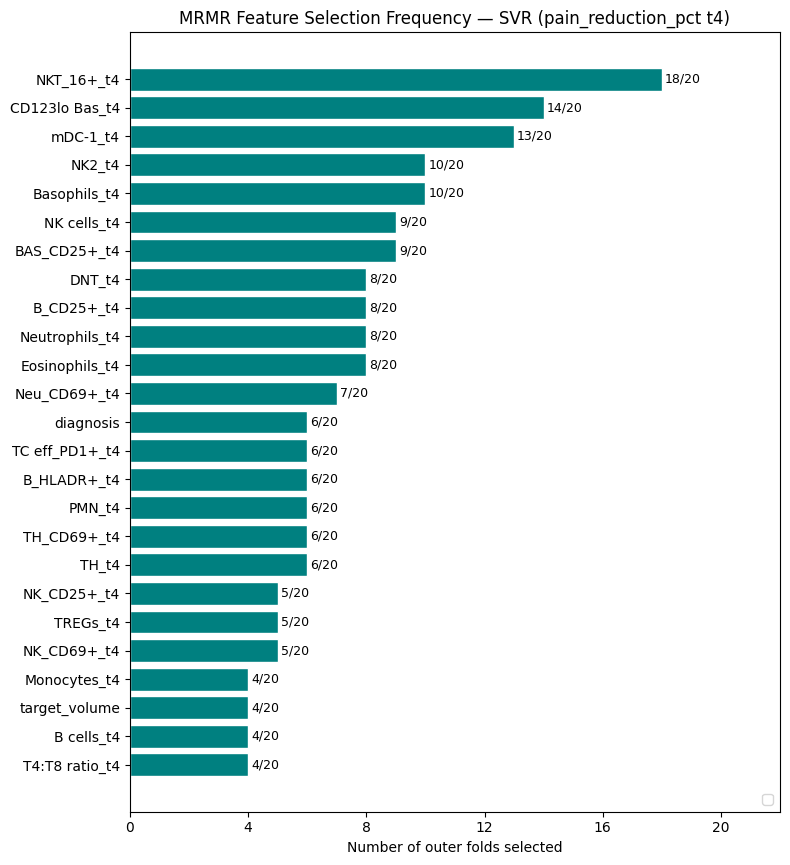

In [6]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'svr_feature_freq4.pkl'))
model.plot_feature_frequency(feature_list, name='SVR (pain_reduction_pct t4)', top=25)

## Jaccard Index of Selected Features
### Pariwise Comparisons for Each Outer Fold (20x20)


  Jaccard Scores — SVR (MRMR Feat. Sel.) t4
  Folds: 20   Pairs evaluated: 190
  Mean Jaccard : 0.185 ± 0.126
  Min  Jaccard : 0.000
  Max  Jaccard : 0.875


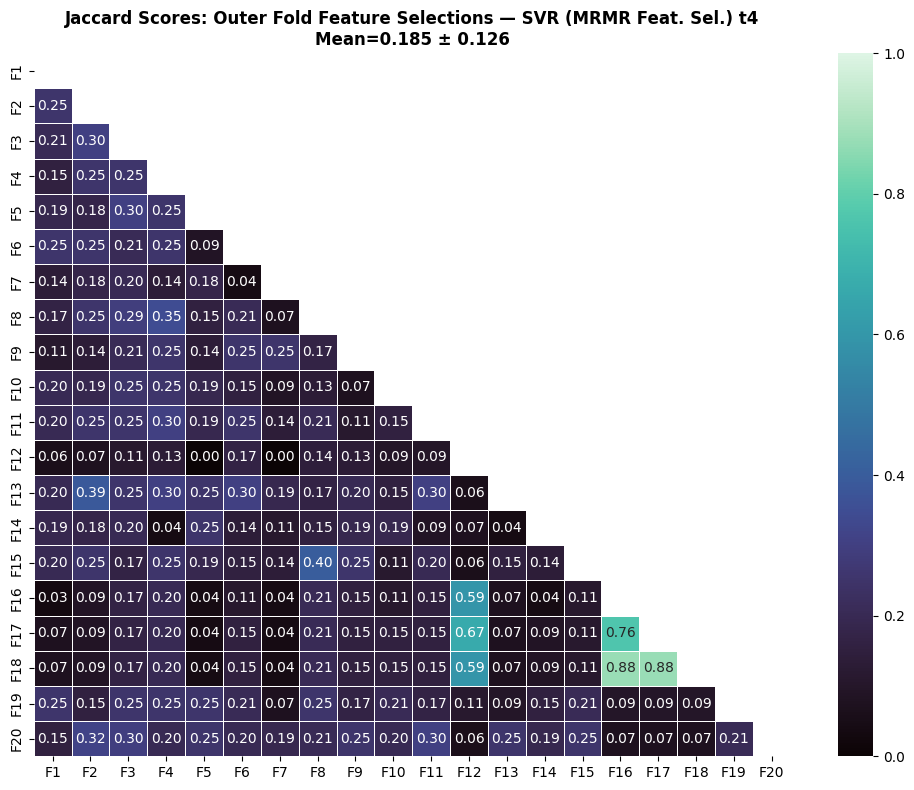

In [7]:
selected_per_fold = joblib.load(os.path.join(MODEL_DIR, 'svr_per_fold4.pkl'))
jac_matrix = model.jaccard_scores(selected_per_fold, name='SVR (MRMR Feat. Sel.) t4')

## SVR on different subsets of selected features

In [8]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'svr_feature_freq4.pkl'))
importlib.reload(model_svr)
svr_sweep_df = model_svr.svr_threshold_analysis(
     df_pain, 
     feature_list, 
     target_col='pain_reduction_pct',
     random_state=42, 
     target_transformer=pt)
joblib.dump(svr_sweep_df,      os.path.join(MODEL_DIR, 'svr_sweep_df4.pkl'))


  Threshold  all ( ):  94 features
  ['NKT_16+_t4', 'CD123lo Bas_t4', 'mDC-1_t4', 'NK2_t4', 'Basophils_t4', 'NK cells_t4', 'BAS_CD25+_t4', 'DNT_t4']...
  Outer Fold  1/20:  Best Trial 39/50  RMSE=1.0041  {'C': 0.0420160858662852, 'epsilon': 0.9496059771495082, 'gamma': 9.445524741356722}
  Outer Fold  2/20:  Best Trial 47/50  RMSE=1.0033  {'C': 0.11754745996522847, 'epsilon': 0.7587551204831776, 'gamma': 1.4020800955677484}
  Outer Fold  3/20:  Best Trial 27/50  RMSE=1.0069  {'C': 3.351234779071516, 'epsilon': 0.27782440060023395, 'gamma': 0.16463332120888538}
  Outer Fold  4/20:  Best Trial 29/50  RMSE=1.0090  {'C': 0.32801870991461307, 'epsilon': 0.7942203017578917, 'gamma': 0.1731948171431001}
  Outer Fold  5/20:  Best Trial 19/50  RMSE=1.0141  {'C': 0.1631497121799349, 'epsilon': 0.962095893149331, 'gamma': 0.35228322327676576}
  Outer Fold  6/20:  Best Trial  1/50  RMSE=0.9994  {'C': 0.31489116479568624, 'epsilon': 0.711447600934342, 'gamma': 0.8471801418819978}
  Outer Fold  7/2

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\svr_sweep_df4.pkl']

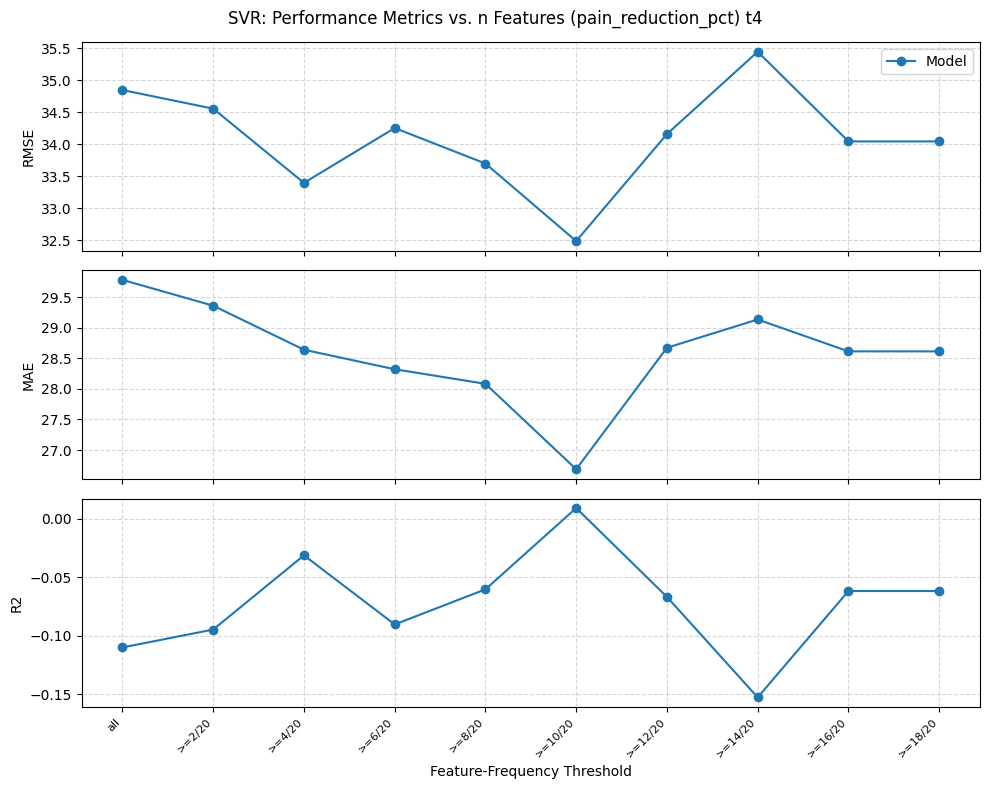

In [9]:
# plot sweep
# Plot performances on different feature-tresholds
importlib.reload(model)
model.plot_sweep(svr_sweep_df, title='SVR: Performance Metrics vs. n Features (pain_reduction_pct) t4')

# Final SVR Model
## Features Selected in >= 10/20 outer folds

In [ ]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'svr_feature_freq4.pkl'))
sel_features = feature_list[feature_list >= 10].index.tolist()

results_svr4, svr_model4, svr_X_final4, svr_y_pred4, svr_patient_err4, svr_err_df4, svr_scaler4, svr_errors4 = model_svr.run_tuned_svr(
    df_pain, 
    sel_features,
    target_col='pain_reduction_pct', 
    random_state=42,
    target_transformer=pt)

# save results
joblib.dump(results_svr4,               os.path.join(MODEL_DIR, 'svr_results4.pkl'))
joblib.dump(svr_model4,                os.path.join(MODEL_DIR, 'svr_model4.pkl'))
joblib.dump(svr_X_final4,              os.path.join(MODEL_DIR, 'svr_X_final4.pkl'))
joblib.dump(svr_patient_err4,          os.path.join(MODEL_DIR, 'svr_patient_err4.pkl'))
joblib.dump(svr_err_df4,               os.path.join(MODEL_DIR, 'svr_err_df4.pkl'))
joblib.dump(svr_scaler4,               os.path.join(MODEL_DIR, 'svr_scaler4.pkl'))
joblib.dump(svr_errors4,               os.path.join(MODEL_DIR, 'svr_errors4.pkl'))


  SVR (RBF) + Optuna — pain_reduction_pct
  n=77, p=5
  Outer 4×5=20 | Inner 4×5=20 | Optuna trials=50

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    Trial   1/50: RMSE=0.9794  {'C': 0.31489116479568624, 'epsilon': 0.711447600934342, 'gamma': 0.8471801418819978}
    Trial   2/50: RMSE=1.0243  {'C': 2.481040974867813, 'epsilon': 0.0029380279387035343, 'gamma': 0.004207053950287938}
    Trial   3/50: RMSE=1.0141  {'C': 0.017073967431528128, 'epsilon': 0.39676050770529875, 'gamma': 0.2537815508265665}
    Trial   4/50: RMSE=1.0950  {'C': 6.79657809075816, 'epsilon': 0.00115279871282324, 'gamma': 7.579479953348009}
    Trial   5/50: RMSE=1.0687  {'C': 21.368329072358772, 'epsilon': 0.004335281794951566, 'gamma': 0.005337032762603957}
    Trial   6/50: RMSE=1.0172  {'C': 0.05415244119402541, 'epsilon': 0.008179499475211672, 'gamma': 0.12561043700013558}
    Trial   7/50: RMSE=0.9982 

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\svr_scaler4.pkl']

## Difficult Patient Predictions

In [12]:
patient_err = joblib.load(os.path.join(MODEL_DIR, 'svr_patient_err4.pkl'))
print(patient_err.to_string())

         mean_mae  n_folds
Patient                   
202         92.51        5
116         80.22        5
239         68.35        5
122         62.51        5
174         60.28        5
91          52.75        5
222         52.70        5
189         50.09        5
169         47.85        5
72          46.99        5
181         44.63        5
93          42.39        5
230         41.23        5
196         40.23        5
177         40.08        5
241         39.87        5
221         37.40        5
164         36.33        5
141         35.68        5
183         35.05        5
188         35.03        5
153         32.90        5
76          32.87        5
107         31.72        5
210         31.27        5
154         31.15        5
134         28.85        5
232         28.39        5
111         28.38        5
16          27.92        5
173         25.29        5
106         25.22        5
176         24.70        5
58          24.59        5
126         24.52        5
1

## Prediction-Error Heatmap

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
seen = []

for e in svr_errors4:
    if e['Patient'] not in seen:
        seen.append(e['Patient'])

heatmap_data = svr_err_df4.loc[seen]

fig, ax = plt.subplots(figsize=(8, max(4, len(heatmap_data) * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'MAE'})
ax.set_title('Per-Patient Absolute Error by Repeat')
ax.set_xlabel('Repeat')
ax.set_ylabel('Patient')
plt.tight_layout()
plt.show()

## SHAP-value Plot


=== SHAP Analysis: SVR ===


  0%|          | 0/129 [00:00<?, ?it/s]

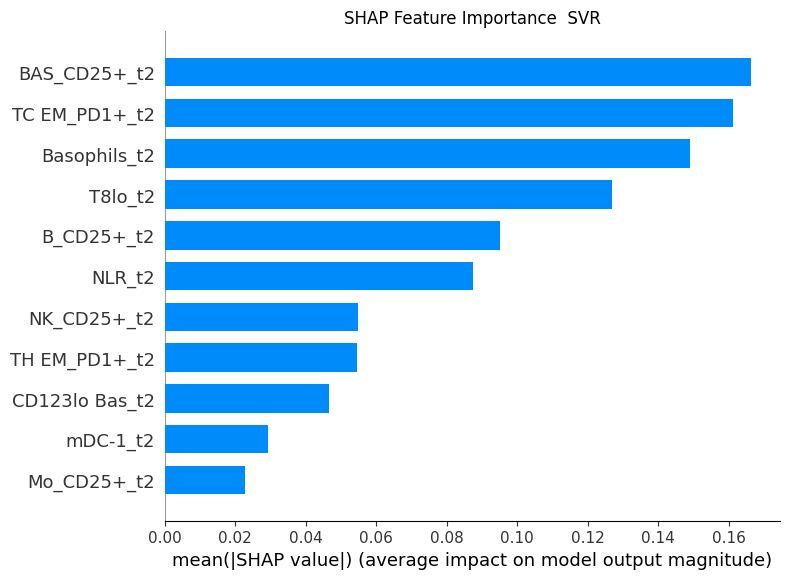

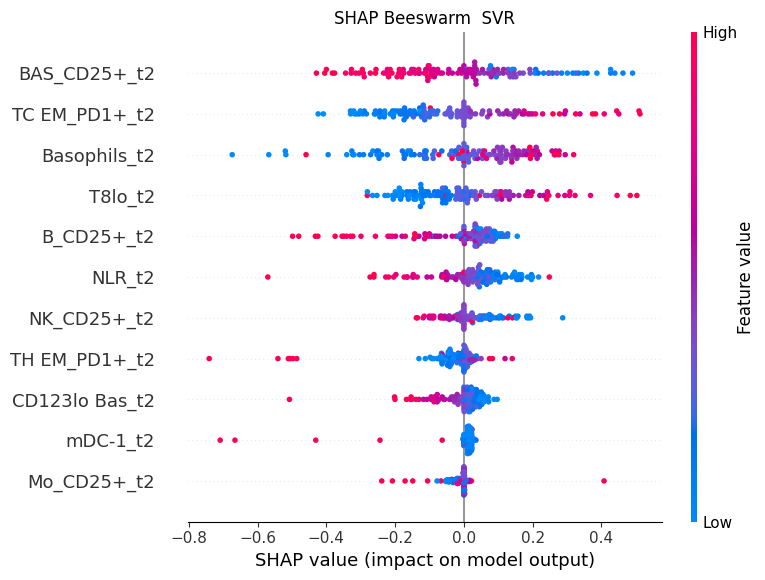

In [11]:
# Plot Shap values
svr_model= joblib.load(os.path.join(MODEL_DIR, 'svr_model.pkl'))
svr_X_final = joblib.load(os.path.join(MODEL_DIR, 'svr_X_final.pkl'))
svr_scaler = joblib.load(os.path.join(MODEL_DIR, 'svr_scaler.pkl'))

svr_shap = model.plot_shap_svr(svr_model, svr_X_final, svr_scaler)